In [1]:


import pandas as pd
import numpy as np
from tqdm import tqdm

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2

import tensorflow
print("TF Version:", tensorflow.__version__)
#tensorflow.config.set_visible_devices([], 'GPU') # Hide the GPU from TF

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

from sklearn.model_selection import train_test_split

# Load CSVs
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.head())
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

# Load a sample image
sample_id = train_df.iloc[0]["Id"]
sample_label = train_df.iloc[0]["Category"]
img_path = Path(f"train/train/{sample_label}/{sample_id}.png")

      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3
Train size: 17000, Test size: 3000


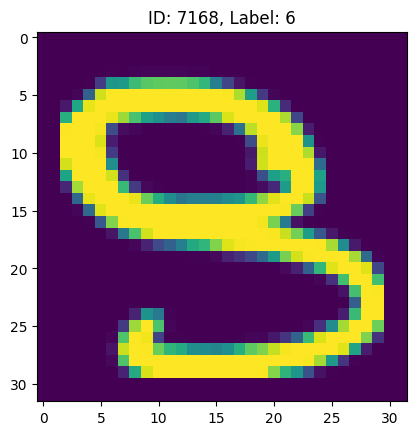

In [26]:
# view original image

img = Image.open(img_path)
plt.imshow(img)
plt.title(f"ID: {sample_id}, Label: {sample_label}")
plt.show()

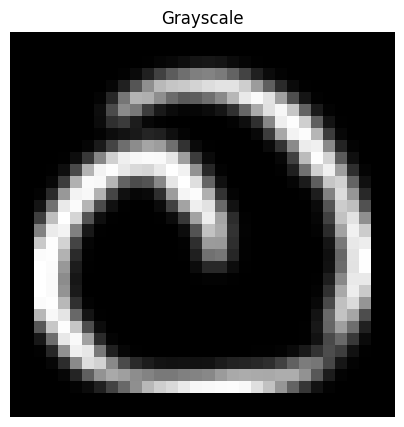

In [27]:
# convert to grayscale
# function from lab 3
def show_images(images, titles, cmap=None):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Pick one image from class 0

img_path = "train/train/0/103265.png"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

show_images([gray], ["Grayscale"])

In [ ]:
# train images to grayscale
# import pandas as pd
# import numpy as np

# train_df = pd.read_csv("train.csv")

# images = []
# labels = []

# for _, row in train_df.iterrows():
#     img_id = row["Id"]
#     label = row["Category"]
#     path = f"train/train/{label}/{img_id}.png"
    
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     images.append(gray)
#     labels.append(label)

# images = np.array(images)
# labels = np.array(labels)

# print(f"Loaded {len(images)} images, shape: {images.shape}")

In [2]:
# # save grayscale images locally
'''
from pathlib import Path

output_dir = Path(os.path.join(BASE_DIR,"train_gray"))
output_dir.mkdir(exist_ok=True)

for _, row in train_df.iterrows():
    img_id = row["Id"]
    label = row["Category"]
    path = os.path.join(BASE_DIR, "train/train", f"{label}/{img_id}.png")

    img = cv2.imread(path)
    if img is None:
        # Instead of crashing, we print a warning and skip
        print(f" Warning: Could not find image at {path}")
        continue
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    cv2.imwrite(str(output_dir / f"{img_id}.png"), gray)

print("Done saving grayscale images")'''

train_df = pd.read_csv("train.csv")

X_mini = []
y_mini = []

print("Starting Mini-Load...")
# Only try 500 images to see if it works
for i in range(500):
    row = train_df.iloc[i]
    img_path = f"train_gray/{row['Id']}.png"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        X_mini.append(img)
        y_mini.append(row['Category'])

X_mini = np.array(X_mini).astype('float32') / 255.0
X_mini = np.expand_dims(X_mini, -1)
print(f"Mini-load done! Shape: {X_mini.shape}")

Starting Mini-Load...
Mini-load done! Shape: (500, 32, 32, 1)


In [24]:

num_samples = len(train_df)
X = np.zeros((num_samples, 32, 32, 1), dtype='float32')
y = train_df["Category"].values

print(f"Allocated memory for {num_samples} images...")

for i, (idx, row) in enumerate(tqdm(train_df.iterrows(), total=num_samples)):
    img_path = f"train_gray/{row['Id']}.png"
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        # Normalize, keep (32, 32, 1) shape
        X[i] = np.expand_dims(img.astype('float32') / 255.0, axis=-1)
    else:
        print(f"Warning: Image {img_path} not found.")


# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=75, stratify=y)

print(f"Final Training Shape: {X_train.shape}") # (n images, 32, 32, 1)


Allocated memory for 17000 images...


100%|███████████████████████████████████| 17000/17000 [00:10<00:00, 1694.70it/s]

Final Training Shape: (12750, 32, 32, 1)


In [28]:
def basis_lenet(input_shape):

  model = keras.models.Sequential()

  model.add(layers.Input(shape=input_shape))
  model.add(layers.Rescaling(1./255))

  model.add(keras.layers.Conv2D(filters=6, strides=(1,1), kernel_size=(5,5), activation='tanh'))
  model.add(layers.BatchNormalization())
  model.add(keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

  model.add(keras.layers.Conv2D(filters=6, strides=(1,1), kernel_size=(5,5), activation='tanh'))
  model.add(layers.BatchNormalization())
  model.add(keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))
    

  # Flatten the output so that we can connect it with the fully connected layer
  model.add(keras.layers.Flatten())
    
  # fully connected layers
  model.add(keras.layers.Dense(units=120, activation='tanh'))
  model.add(layers.BatchNormalization())
  model.add(keras.layers.Dense(units=84, activation='tanh'))
  model.add(layers.BatchNormalization())
    
  # output 
  model.add(keras.layers.Dense(units=10, activation='softmax'))

  return model

def get_model(input_shape):
    model = keras.models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Rescaling(1./255))

    # More filters (32 instead of 6) and 'relu' instead of 'tanh'
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    
    model.add(layers.Dense(10, activation='softmax'))
    return model

Epoch 1/100
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8820 - loss: 0.3754
Epoch 1: val_accuracy improved from -inf to 0.19835, saving model to best_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8823 - loss: 0.3745 - val_accuracy: 0.1984 - val_loss: 2.9212
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9831 - loss: 0.0592
Epoch 2: val_accuracy improved from 0.19835 to 0.98824, saving model to best_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9831 - loss: 0.0592 - val_accuracy: 0.9882 - val_loss: 0.0590
Epoch 3/100
396/399 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9911 - loss: 0.0329
Epoch 3: val_accuracy did not improve from 0.98824
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9911 - loss: 0.0330 - val_accuracy: 0.9835 - val_loss: 0.0560
Epoch 4/100
396/399 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9919 - loss: 0.0284
Epoch 4: val_accuracy improved from 0.98824 to 0.99129, saving model

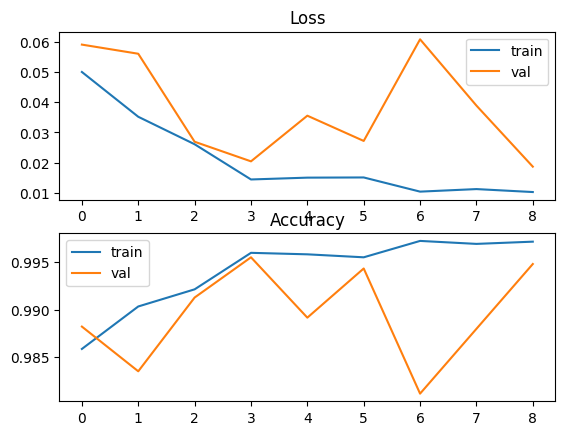

In [31]:
model = get_model((32,32,1))

#train model
opt = keras.optimizers.Adam(learning_rate=.001)

model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=["accuracy"])

#history = model.fit(X_mini, np.array(y_mini), epochs=1, verbose=1)
#history = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=32, epochs=2, verbose=2)
#saved_model = model

es = EarlyStopping(monitor='val_accuracy', mode='max', verbose=1, patience=5, min_delta=0.001)
mc = ModelCheckpoint('best_model.keras', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=32, epochs=100, callbacks=[es, mc])
#load saved model
saved_model = load_model('best_model.keras')

# evaluate model
_, train_acc = saved_model.evaluate(X_train, y_train, verbose=0)
_, val_acc = saved_model.evaluate(X_val, y_val, verbose=0)
print('Train: %.3f, Validation: %.3f' % (train_acc, val_acc))

# plot loss during training
plt.subplot(211)
plt.title('Loss')
plt.plot(history.history['loss'][1:], label='train')
plt.plot(history.history['val_loss'][1:], label='val')
plt.legend()
# plot accuracy during training
print('')
print('')
plt.subplot(212)
plt.title('Accuracy')
plt.plot(history.history['accuracy'][1:], label='train')
plt.plot(history.history['val_accuracy'][1:], label='val')
plt.legend()
plt.show()

basis lenet: Train: 0.967, Validation: 0.960 
with maxpooling and dropout: Train: 0.998, Validation: 0.996

In [34]:
import keras
from keras import layers
import keras_tuner as kt
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

def build_model(hp):
    model = keras.models.Sequential()
    model.add(layers.Input(shape=(32, 32, 1)))
    model.add(layers.Rescaling(1./255))

    # set number of filters, neurons in dense layers, activation function and dropout as a hyperparameters to be tuned
    hp_filters = hp.Int('filters', min_value=4, max_value=64, step=16)
    hp_activation = hp.Choice('activation', values=['relu', 'tanh'])


    model.add(layers.Conv2D(hp_filters, (3, 3), activation=hp_activation, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(hp_filters * 2, (3, 3), activation=hp_activation, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    
    hp_dropout = hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)
    model.add(layers.Dropout(hp_dropout))

    hp_units = hp.Int('dense_units', min_value=64, max_value=256, step=64)
    model.add(layers.Dense(units=hp_units, activation=hp_activation))
    model.add(layers.BatchNormalization())
    
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model
    

# Initialize the Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # amount of combinations to try
    executions_per_trial=1, # number of models per combination, doing this takes much longer but it is then more accurate. now for rough estimations not yet necessary
    directory='hyperparam_search',
    project_name='lenet_tuning'
)

# Run the search
es = EarlyStopping(monitor='val_loss', patience=5)
tuner.search(X_train, y_train, epochs=20, validation_data=(X_val, y_val), callbacks=[es])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

Trial 10 Complete [00h 00m 41s]
val_accuracy: 0.9929412007331848

Best val_accuracy So Far: 0.9957647323608398
Total elapsed time: 00h 20m 13s


In [36]:
print(f"""
The optimal configuration:

- Filters (Base): {best_hps.get('filters')}
- Activation:     {best_hps.get('activation')}
- Dropout Rate:   {best_hps.get('dropout'):.2f}
- Dense Units:    {best_hps.get('dense_units')}
""")
tuner.results_summary()


The optimal configuration:

- Filters (Base): 64
- Activation:     relu
- Dropout Rate:   0.40
- Dense Units:    256

Results summary
Results in hyperparam_search/lenet_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 05 summary
Hyperparameters:
filters: 64
activation: relu
dropout: 0.4
dense_units: 256
Score: 0.9957647323608398

Trial 02 summary
Hyperparameters:
filters: 64
activation: relu
dropout: 0.30000000000000004
dense_units: 256
Score: 0.9934117794036865

Trial 09 summary
Hyperparameters:
filters: 16
activation: relu
dropout: 0.0
dense_units: 256
Score: 0.9929412007331848

Trial 03 summary
Hyperparameters:
filters: 64
activation: relu
dropout: 0.30000000000000004
dense_units: 192
Score: 0.9922353029251099

Trial 00 summary
Hyperparameters:
filters: 32
activation: tanh
dropout: 0.1
dense_units: 64
Score: 0.34917646646499634

Trial 06 summary
Hyperparameters:
filters: 32
activation: tanh
dropout: 0.4
dense_units: 192
Score: 0.28423529863357544

In [39]:

def build_model_v2(hp):
    model = keras.models.Sequential()
    model.add(layers.Input(shape=(32, 32, 1)))
    model.add(layers.Rescaling(1./255))

    hp_filter1 = hp.Int('filter1', min_value=4, max_value=64, step=16)
    hp_filter2 = hp.Int('filter2', min_value=4, max_value=64, step=16)

    if hp.Boolean('max_pooling'):
        model.add(layers.Conv2D(hp_filter1, (3, 3), activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))
        
        model.add(layers.Conv2D(hp_filter2, (3, 3), activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))
    else:
        model.add(layers.Conv2D(hp_filter1, (3, 3), activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.AveragePooling2D((2, 2)))
        
        model.add(layers.Conv2D(hp_filter2, (3, 3), activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.AveragePooling2D((2, 2)))

    model.add(layers.Flatten())
    
    hp_dropout = hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)
    model.add(layers.Dropout(hp_dropout))

    hp_units = hp.Int('dense_units', min_value=64, max_value=256, step=20)
    model.add(layers.Dense(units=hp_units, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(hp_dropout))

    if hp.Boolean('add_second_dense'):
        hp_unit2 = hp.Int('dense_unit2', min_value=64, max_value=256, step=20)
        model.add(layers.Dense(units=hp_unit2, activation='relu')) 
        model.add(layers.BatchNormalization())
        
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

tuner = kt.BayesianOptimization(
    build_model_v2,
    objective='val_accuracy',
    max_trials=20,
    directory='hyperparam_search',
    project_name='CNN_tuning_2'
)

tuner.search(X_train, y_train, epochs=15, validation_data=(X_val, y_val))

Trial 20 Complete [00h 01m 30s]
val_accuracy: 0.9851764440536499

Best val_accuracy So Far: 0.9959999918937683
Total elapsed time: 00h 53m 26s


In [41]:
tuner.results_summary(num_trials=20)

Results summary
Results in hyperparam_search/CNN_tuning_2
Showing 20 best trials
Objective(name="val_accuracy", direction="max")

Trial 08 summary
Hyperparameters:
filter1: 20
filter2: 20
max_pooling: False
dropout: 0.1
dense_units: 224
add_second_dense: True
dense_unit2: 244
Score: 0.9959999918937683

Trial 04 summary
Hyperparameters:
filter1: 4
filter2: 52
max_pooling: False
dropout: 0.4
dense_units: 224
add_second_dense: True
dense_unit2: 184
Score: 0.9952940940856934

Trial 09 summary
Hyperparameters:
filter1: 4
filter2: 20
max_pooling: True
dropout: 0.2
dense_units: 64
add_second_dense: False
dense_unit2: 204
Score: 0.9952940940856934

Trial 18 summary
Hyperparameters:
filter1: 36
filter2: 36
max_pooling: True
dropout: 0.4
dense_units: 164
add_second_dense: True
dense_unit2: 124
Score: 0.9952940940856934

Trial 10 summary
Hyperparameters:
filter1: 52
filter2: 20
max_pooling: False
dropout: 0.30000000000000004
dense_units: 84
add_second_dense: True
dense_unit2: 244
Score: 0.9950588

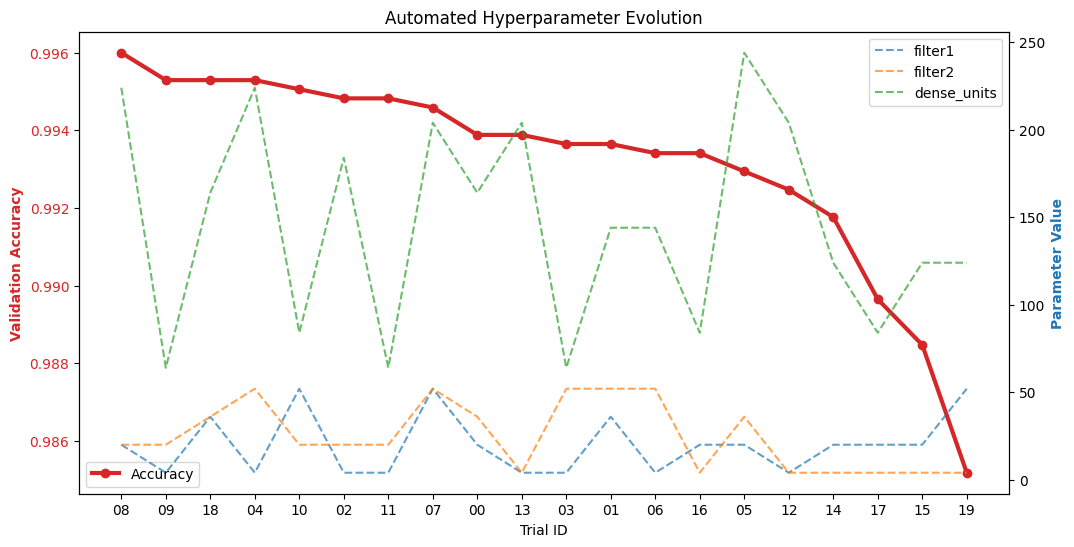

In [44]:
import pandas as pd

#get the results to a pandas dataframe so we can make visualizations

trials = tuner.oracle.get_best_trials(num_trials=20)
results = []

for trial in trials:
    data = trial.hyperparameters.values.copy()
    data['score'] = trial.score
    data['trial_id'] = trial.trial_id
    results.append(data)

df = pd.DataFrame(results)

df['max_pooling'] = df['max_pooling'].astype(int) # Ccnvert True/False to 1/0
df = df.sort_values('score', ascending=False)   # sort by best to worst performance



#make the plot

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Trial ID')
ax1.set_ylabel('Validation Accuracy', color='tab:red', fontweight='bold')
ax1.plot(df['trial_id'], df['score'], color='tab:red', marker='o', linewidth=3, label='Accuracy')
ax1.tick_params(axis='y', labelcolor='tab:red')


ax2 = ax1.twinx()
ax2.set_ylabel('Parameter Value', color='tab:blue', fontweight='bold')
for param in ['filter1', 'filter2', 'dense_units']:
    if param in df.columns:
        ax2.plot(df['trial_id'], df[param], label=param, linestyle='--', alpha=0.7)

plt.title('Automated Hyperparameter Evolution')
ax1.legend(loc='lower left')
ax2.legend(loc='upper right')
plt.show()

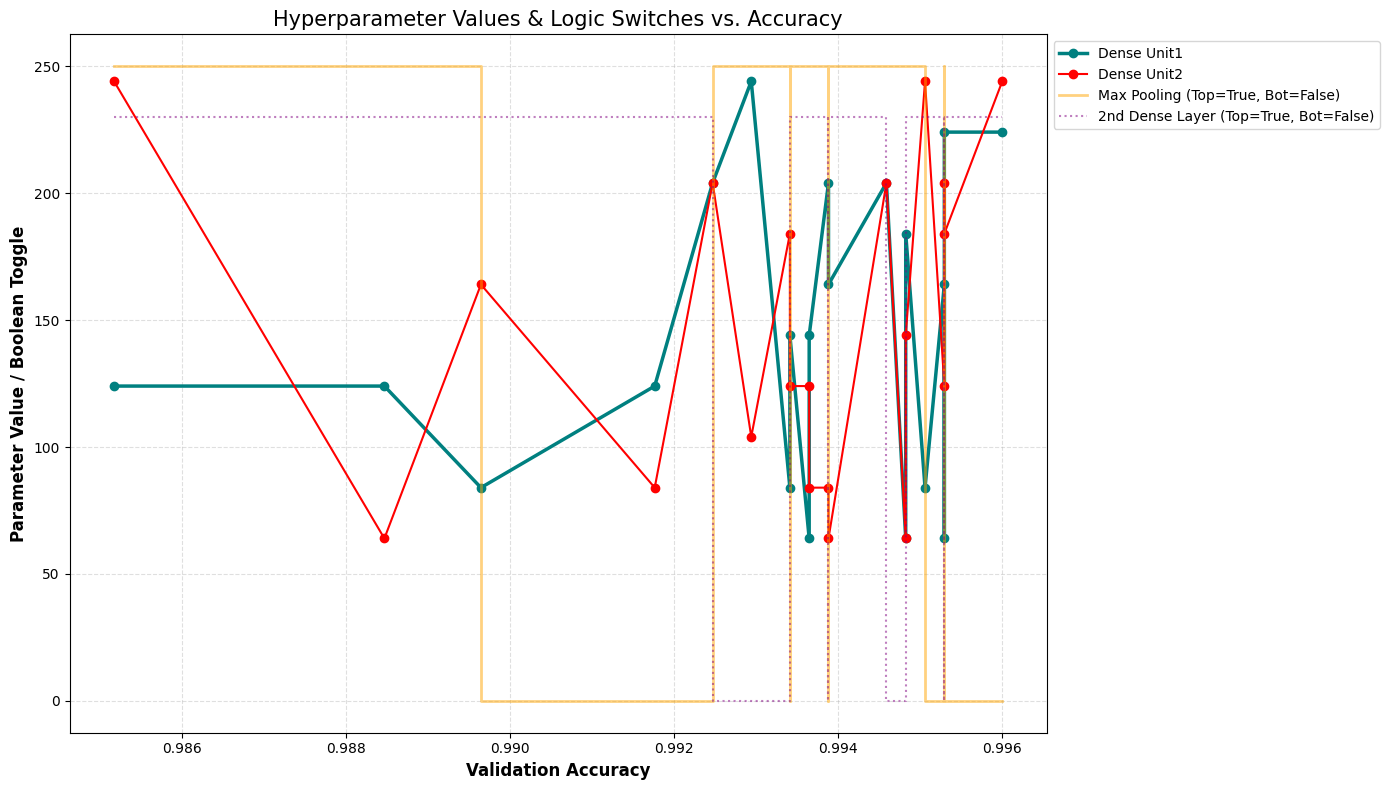

In [54]:

trials = tuner.oracle.get_best_trials(num_trials=20)
results = []
for t in trials:
    d = t.hyperparameters.values.copy()
    d['score'] = t.score
    results.append(d)

df = pd.DataFrame(results).sort_values('score')

fig, ax = plt.subplots(figsize=(14, 8))


ax.plot(df['score'], df['filter1'], marker='s', label='Filter 1', linestyle='--', alpha=0.7)
ax.plot(df['score'], df['filter2'], marker='^', label='Filter 2', linestyle='--', alpha=0.7)
ax.plot(df['score'], df['dropout']*10, marker='^', label='Dropout rate * 10', linestyle='--', alpha=0.7)

#comment out whatever you'd like to see clearly

'''
ax.plot(df['score'], df['dense_units'], marker='o', label='Dense Unit1', linewidth=2.5, color='teal')
ax.plot(df['score'], df['dense_unit2'], marker='o', label='Dense Unit2', color='red')


# boolean parameters, scaled to be visible
ax.step(df['score'], df['max_pooling'].astype(int) * 250, where='post', 
        label='Max Pooling (Top=True, Bot=False)', color='orange', alpha=0.5, linewidth=2)

if 'add_second_dense' in df.columns:
    ax.step(df['score'], df['add_second_dense'].astype(int) * 230, where='post', 
            label='2nd Dense Layer (Top=True, Bot=False)', color='purple', alpha=0.5, linestyle=':')
'''


ax.set_xlabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Parameter Value / Boolean Toggle', fontsize=12, fontweight='bold')
ax.set_title('Hyperparameter Values & Logic Switches vs. Accuracy', fontsize=15)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

Analysis:
it is a bit difficult to get conclusions since the accuracies are very close to eachother, and the accuracy is different everytime you run it. Also, the graphs are very spikey. however, we still can get some information from it. we could finetune this further later on

pooling: doesnt seem to matter to much, but the top two trials use average pooling so lets go with that
second dense layer: top 2, and most trials in top 10 trials, did benefit from this. so lets keep it with around 150-250 neurons
filters: both around 20 seems best
dropout: very difficult to see. something between 0.1-0.4...



for a more efficient model, we could ofcourse also take the from trial 9, which has only one fully connected layer with way less neurons, and has less filters and a very comparable performance.
but for our application, efficiency doesnt matter too much and performance way more

so for now, we can take trial 8 and tune it further or try more things